# Predicting Critical Training Overload
## Data Exploration

Date: Spring 2025
Authors: Yaman Aljnadi & Cédric Keller

The code uses the data from and is inspired by the following paper:
S. Lovdal, R. van der Hartigh, G. Azzopardi, "Injury Prediction in Competitive Runners With Machine Learning", International Journal of Sports Physiology and Performance, https://doi.org/10.1123/ijspp.2020-0518, 2021

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Main_Codes/day_approach_maskedID_timeseries.csv")
df_week = pd.read_csv("../Main_Codes/week_approach_maskedID_timeseries.csv")

### Daily Data

In [3]:
df.head()

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,km sprinting,strength training,hours alternative,perceived exertion,perceived trainingSuccess,perceived recovery,...,km Z5-T1-T2.6,km sprinting.6,strength training.6,hours alternative.6,perceived exertion.6,perceived trainingSuccess.6,perceived recovery.6,Athlete ID,injury,Date
0,1.0,5.8,0.0,0.6,1.2,0.0,0.00,0.11,0.00,0.18,...,0.0,0.0,0.0,1.0,0.10,0.00,0.15,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.5,1.2,0.0,0.0,0.10,0.00,0.17,0,0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,0.00,0.10,0.00,0.17,...,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,0,0,2
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.0,0.0,1.0,0.0,0.10,0.00,0.17,0,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,1.08,0.08,0.00,0.18,...,0.0,0.0,0.0,0.0,0.11,0.00,0.17,0,0,4


In [4]:
df.columns

Index(['nr. sessions', 'total km', 'km Z3-4', 'km Z5-T1-T2', 'km sprinting',
       'strength training', 'hours alternative', 'perceived exertion',
       'perceived trainingSuccess', 'perceived recovery', 'nr. sessions.1',
       'total km.1', 'km Z3-4.1', 'km Z5-T1-T2.1', 'km sprinting.1',
       'strength training.1', 'hours alternative.1', 'perceived exertion.1',
       'perceived trainingSuccess.1', 'perceived recovery.1', 'nr. sessions.2',
       'total km.2', 'km Z3-4.2', 'km Z5-T1-T2.2', 'km sprinting.2',
       'strength training.2', 'hours alternative.2', 'perceived exertion.2',
       'perceived trainingSuccess.2', 'perceived recovery.2', 'nr. sessions.3',
       'total km.3', 'km Z3-4.3', 'km Z5-T1-T2.3', 'km sprinting.3',
       'strength training.3', 'hours alternative.3', 'perceived exertion.3',
       'perceived trainingSuccess.3', 'perceived recovery.3', 'nr. sessions.4',
       'total km.4', 'km Z3-4.4', 'km Z5-T1-T2.4', 'km sprinting.4',
       'strength training.4',

In [5]:
df.describe()

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,km sprinting,strength training,hours alternative,perceived exertion,perceived trainingSuccess,perceived recovery,...,km Z5-T1-T2.6,km sprinting.6,strength training.6,hours alternative.6,perceived exertion.6,perceived trainingSuccess.6,perceived recovery.6,Athlete ID,injury,Date
count,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,...,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000,42766.000000
mean,0.829561,7.038187,0.691381,0.579930,0.073016,0.116237,0.163492,0.247788,0.349802,0.195898,...,0.580347,0.072595,0.116120,0.162308,0.247550,0.349503,0.196224,34.550858,0.013632,1228.039892
std,0.580696,7.473216,2.317657,1.811938,0.483480,0.326010,0.549664,0.257262,0.368300,0.190321,...,1.814538,0.483691,0.326016,0.554031,0.256718,0.368042,0.190568,19.050033,0.115960,807.021168
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,...,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,...,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,20.000000,0.000000,436.000000
50%,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.160000,0.260000,0.160000,...,0.000000,0.000000,0.000000,0.000000,0.160000,0.260000,0.170000,34.000000,0.000000,1256.000000
75%,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.440000,0.720000,0.300000,...,0.000000,0.000000,0.000000,0.000000,0.440000,0.720000,0.300000,50.000000,0.000000,1913.000000
max,2.000000,55.900000,42.200000,48.000000,40.000000,2.000000,10.220000,1.000000,1.000000,1.000000,...,48.000000,40.000000,2.000000,20.000000,1.000000,1.000000,1.000000,73.000000,1.000000,2673.000000


| Daily Feature ([feature].[day_0-6]) | Description |
|---|---|
| **nr. sessions**              | number of trainings completed |
| **total km**                  | number of kilometers covered by running |
| **km Z3-4**                   | number of kilometers covered in intensity zones three and four, running on or slightly above the anaerobic threshold |
| **km Z5-T1-T2**               | number of kilometers covered in intensity zone five, close to maximum heart rate, or intensive track intervals (T1 for longer repetitions and T2 for shorter) |
| **km sprinting**              | number of kilometers covered with sprints |
| **strength training**         | whether the day included a strength training |
| **hours alternative**         | number of hours spent on cross training |
| **perceived exertion**        | athlete's own estimation of how tired they were after completing the main session of the day. In case of of a rest day, this value will be -0.01 |
| **perceived trainingSuccess** | athlete's own estimation of how well the session went. In case of of a rest day, this value will be -0.01 |
| **perceived recovery**        | athlete's own estimation of how well rested they felt before the start of the session. In case of of a rest day, this value will be -0.01 |

The daily data contains all features for each of the six days before an event (injury or non-injury).

| Other Features | Description |
|---|---|
| **Athlete ID**               | represents different athletes |
| **injury**                   | binary representation of training result on event day (7) (injury (1), non-injury (0)) |
| **Date**                     | event day, relative to the first record in the data set |

In [6]:
day_hist_filtered_cols = [col for col in df.columns if not col.endswith(tuple(f".{i}" for i in range(7)))] # only day 0 specific features
day_hist_filtered_cols

['nr. sessions',
 'total km',
 'km Z3-4',
 'km Z5-T1-T2',
 'km sprinting',
 'strength training',
 'hours alternative',
 'perceived exertion',
 'perceived trainingSuccess',
 'perceived recovery',
 'Athlete ID',
 'injury',
 'Date']

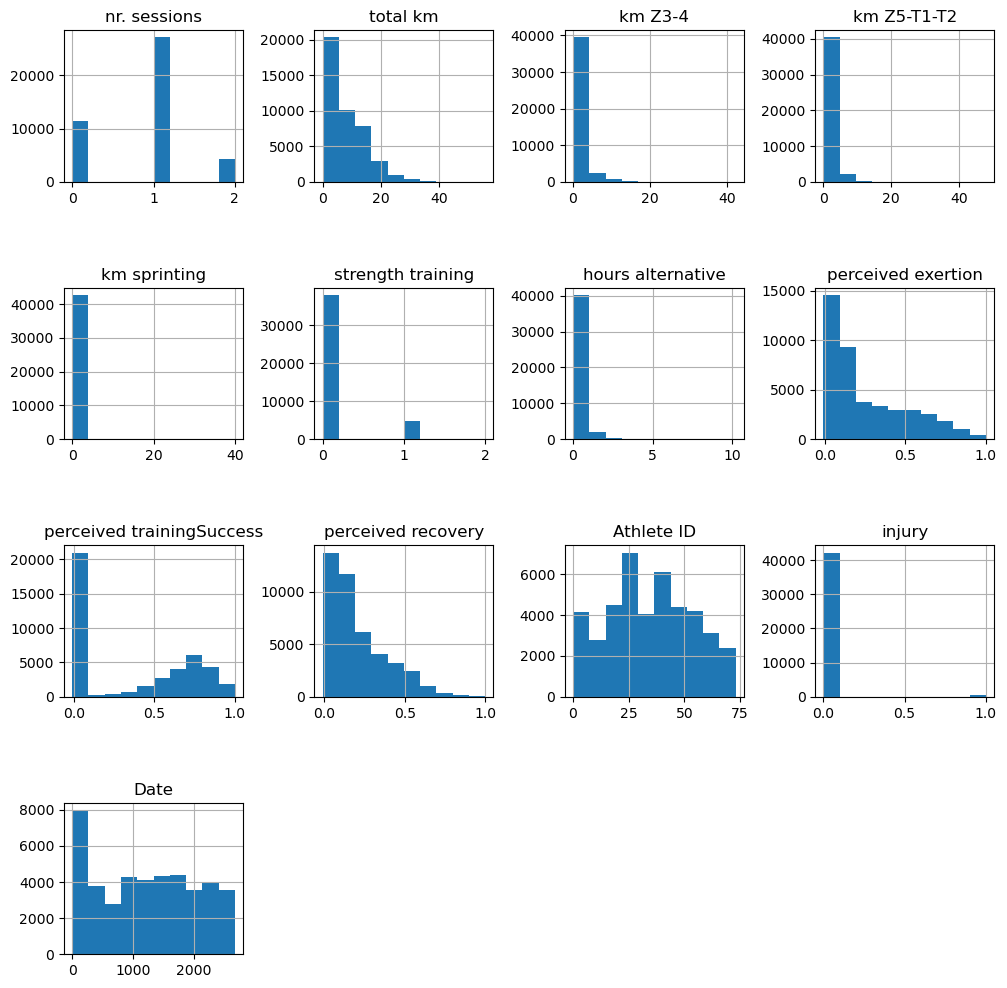

In [7]:
df[day_hist_filtered_cols].hist(figsize=(12,12))
plt.subplots_adjust(hspace=0.7, wspace=0.4);

In [ ]:
injury_vals_day = df.injury.value_counts()
injury_vals_day, str(f"Injuries: {round(injury_vals_day[1] / (injury_vals_day[0]+injury_vals_day[1])*100, 2)}%")

(injury
 0    42183
 1      583
 Name: count, dtype: int64,
 'Injuries: 1.36%')

The histograms above show the distribution of a subset of the daily data (only the features of the first day of the event week, `Athlete ID`, `injury`, and `Date`).

The training features either follow a binary or a decaying distribution, except for `perceived trainingSuccess`, where we have a left-skewed distribution with a high number of rest days (column at -0.01).

The `Athlete ID` plot shows that we have varying numbers of weeks of training data between athletes.

It is apparent in the `injury` plot that we have a highly imbalanced dataset (~1.36% is an injury).

The `Date` plot is stable after an initial drop off. This suggests that the dataset contains a stable number of athletes/records over time.

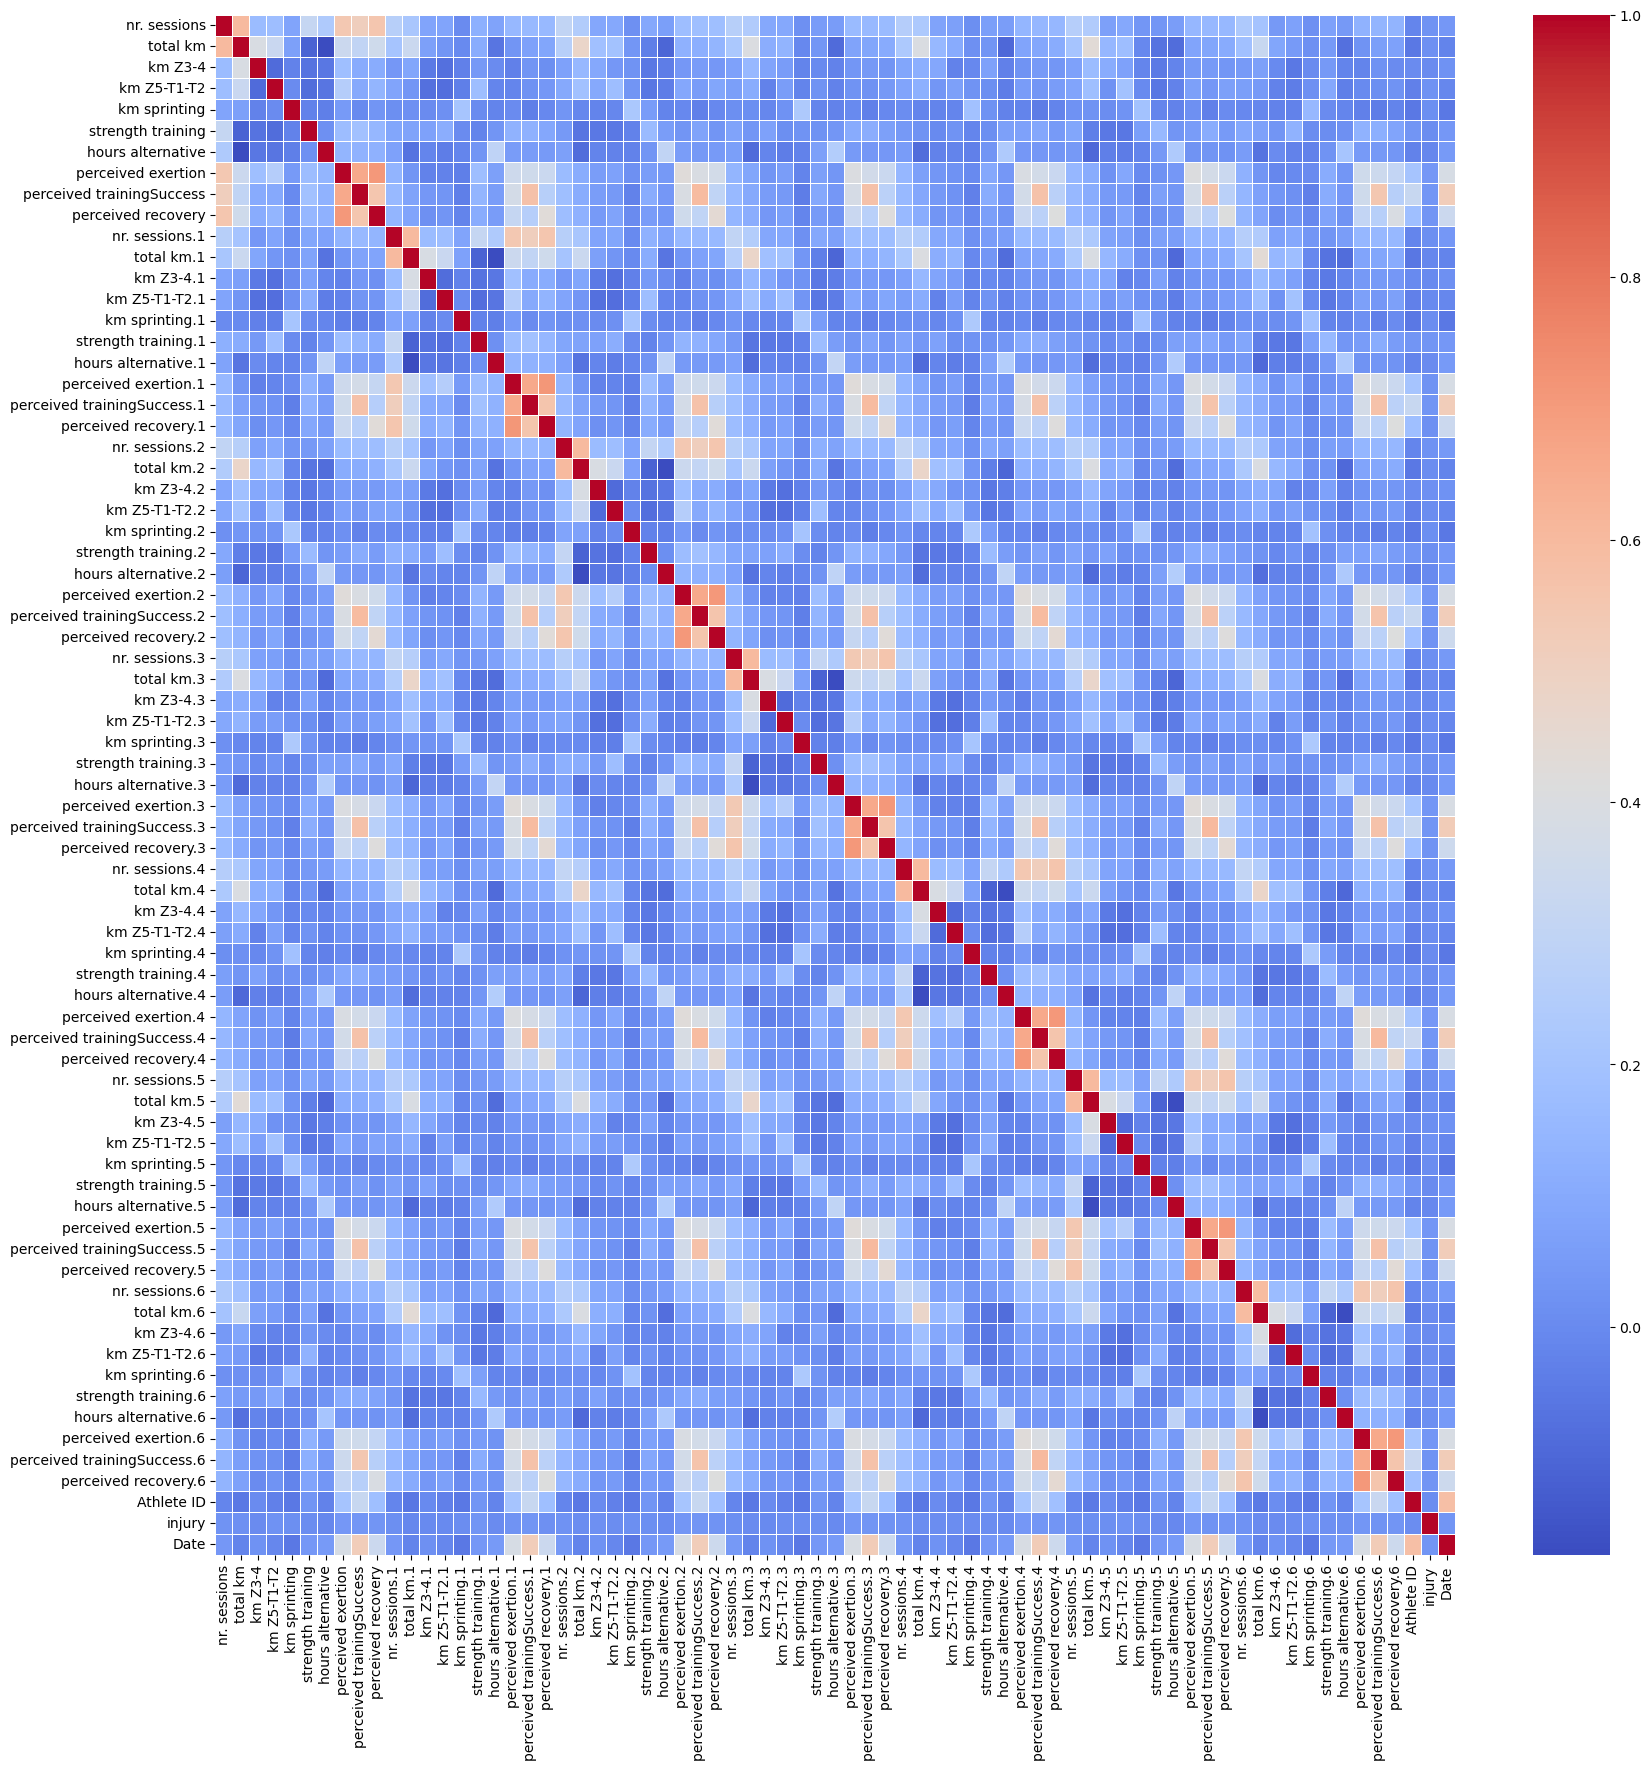

In [9]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=.5);

The correlation heatmap does not show a linear relationship between any of the features and whether or not an injury occurs. Moderate correlation is visible between the perceived features of the different days and the date. The prediction at hand appears to be more complex than a linear problem.

In [10]:
df.isna().any().sum()

0

There are no missing values in the dataset. Based on the previous initial observation, the data appears clean.

### Weekly Data

In [11]:
df_week.head()

,nr. sessions,nr. rest days,total kms,max km one day,total km Z3-Z4-Z5-T1-T2,"nr. tough sessions (effort in Z5, T1 or T2)",nr. days with interval session,total km Z3-4,max km Z3-4 one day,total km Z5-T1-T2,...,max training success.2,avg recovery.2,min recovery.2,max recovery.2,Athlete ID,injury,rel total kms week 0_1,rel total kms week 0_2,rel total kms week 1_2,Date
0,5.0,2.0,22.2,16.4,11.8,1.0,2.0,10.0,10.0,0.6,...,0.0,0.18,0.16,0.20,0,0,0.718447,1.378882,1.919255,0
1,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.18,0.16,0.20,0,0,0.683544,1.018868,1.490566,1
2,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.17,0.16,0.18,0,0,0.683544,1.018868,1.490566,2
3,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.18,0.16,0.18,0,0,0.683544,1.018868,1.490566,3
4,6.0,1.0,39.2,17.6,18.9,1.0,3.0,17.2,10.0,0.5,...,0.0,0.17,0.16,0.18,0,0,2.202247,1.361111,0.618056,4


In [12]:
df_week.columns

Index(['nr. sessions', 'nr. rest days', 'total kms', 'max km one day',
       'total km Z3-Z4-Z5-T1-T2',
       'nr. tough sessions (effort in Z5, T1 or T2)',
       'nr. days with interval session', 'total km Z3-4',
       'max km Z3-4 one day', 'total km Z5-T1-T2', 'max km Z5-T1-T2 one day',
       'total hours alternative training', 'nr. strength trainings',
       'avg exertion', 'min exertion', 'max exertion', 'avg training success',
       'min training success', 'max training success', 'avg recovery',
       'min recovery', 'max recovery', 'nr. sessions.1', 'nr. rest days.1',
       'total kms.1', 'max km one day.1', 'total km Z3-Z4-Z5-T1-T2.1',
       'nr. tough sessions (effort in Z5, T1 or T2).1',
       'nr. days with interval session.1', 'total km Z3-4.1',
       'max km Z3-4 one day.1', 'total km Z5-T1-T2.1',
       'max km Z5-T1-T2 one day.1', 'total hours alternative training.1',
       'nr. strength trainings.1', 'avg exertion.1', 'min exertion.1',
       'max exertion.

In [13]:
df_week.describe()

,nr. sessions,nr. rest days,total kms,max km one day,total km Z3-Z4-Z5-T1-T2,"nr. tough sessions (effort in Z5, T1 or T2)",nr. days with interval session,total km Z3-4,max km Z3-4 one day,total km Z5-T1-T2,...,max training success.2,avg recovery.2,min recovery.2,max recovery.2,Athlete ID,injury,rel total kms week 0_1,rel total kms week 0_2,rel total kms week 1_2,Date
count,42798.000000,42798.000000,42798.000000,42798.000000,42798.000000,42798.000000,42798.000000,42798.000000,42798.000000,42798.000000,...,42798.000000,42798.000000,42798.000000,42798.000000,42798.000000,42798.000000,4.279800e+04,4.279800e+04,4.279800e+04,42798.000000
mean,5.809337,1.874667,49.543911,14.009255,9.433621,0.930184,1.672531,4.859398,3.456888,4.063970,...,0.525709,0.255089,0.184927,0.343522,34.538249,0.013435,4.408628e+05,9.014685e+05,4.803623e+05,1227.733422
std,2.484234,1.853287,36.715017,9.071678,8.887120,1.040631,1.263528,6.984670,4.577423,5.645305,...,0.390604,0.153214,0.127996,0.219536,19.020826,0.115130,4.328234e+06,6.945503e+06,4.656806e+06,806.495152
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,5.000000,1.000000,22.800000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.150000,0.110000,0.170000,20.000000,0.000000,6.955245e-01,6.723968e-01,6.923077e-01,437.000000
50%,6.000000,1.000000,44.800000,13.400000,8.000000,1.000000,2.000000,0.000000,0.000000,1.500000,...,0.730000,0.220000,0.160000,0.310000,34.000000,0.000000,9.891862e-01,1.001431e+00,9.897523e-01,1254.000000
75%,7.000000,3.000000,70.100000,18.300000,14.600000,2.000000,3.000000,8.000000,6.300000,6.300000,...,0.840000,0.360000,0.240000,0.520000,50.000000,0.000000,1.320515e+00,1.422171e+00,1.327586e+00,1913.000000
max,14.000000,7.000000,242.000000,131.000000,100.000000,6.000000,7.000000,79.800000,75.000000,80.000000,...,1.000000,0.900000,0.900000,1.000000,73.000000,1.000000,2.096000e+08,2.176000e+08,2.096000e+08,2673.000000


| Daily Feature ([feature].[week_0-2]) | Description |
|---|---|
| **nr. sessions**                     | total number of sessions completed |
| **nr. rest days**                    | number of days without a training |
| **total kms**                        | total running mileage |
| **max km one day**                   | the maximum number of kilometers completed by running on a single day |
| **total km Z3-Z4-Z5-T1-T2**          | the total number of kilometers done in Z3 or faster, corresponding to running on or above the anaerobic threshold |
| **nr. tough sessions**               | effort in Z5, T1, T2, corresponding to running close to maximum effort and/or intensive track intervals |
| **nr. days with interval session**   | number of days that contained a session in Z3 or faster |
| **total km Z3-4**                    | number of kilometers covered in Z3-4 |
| **max km Z3-4 one day**              | furthest distance ran in Z3-4 on a single day |
| **total km Z5-T1-T2**                | total distance ran in Z5-T1-T2 |
| **max km Z5-T1-T2 one day**          | furthest distance ran in Z5-T1-T2 on a single day |
| **total hours alternative training** | total time spent on cross training |
| **nr. strength trainings**           | number of strength trainings completed |
| **avg exertion**                     | the average rating in exertion based on the athlete's own perception of how tough each training has been |
| **min exertion**                     | the smallest rating in exertion of all trainings of the week |
| **max exertion**                     | the highest rating in exertion of all trainings of the week |
| **avg training success**             | the average rating in how well each training went, according to the athlete's own perception |
| **min training success**             | the smallest rating in training success of the week |
| **max training success**             | the highest rating in training success of the week |
| **avg recovery**                     | the average rating in how well rested the athlete felt before each session |
| **min recovery**                     | the smallest rating in how well rested the athlete felt before a session |
| **max recovery**                     | the highest rating in how well rested the athlete felt before a session |

The weekly data contains all above features for each of the three weeks before an event (injury or non-injury).

| Other Features | Description |
|---|---|
| **Athlete ID**                       | represents different athletes |
| **injury**                           | binary representation of training result on event day (7) (injury (1), non-injury (0)) |
| **rel total kms week 0_1**           | training volume change week 0 to week 1 (total distance week 0 / total distance week 1) |
| **rel total kms week 0_2**           | training volume change week 0 to week 2 (total distance week 0 / total distance week 2) |
| **rel total kms week 1_2**           | training volume change week 1 to week 2 (total distance week 1 / total distance week 2) |
| **Date**                             | event day, relative to the first record in the data set |

In [14]:
week_hist_filtered_cols = [col for col in df_week.columns if not col.endswith(tuple(f".{i}" for i in range(3)))] # only week 0 specific features
week_hist_filtered_cols

['nr. sessions',
 'nr. rest days',
 'total kms',
 'max km one day',
 'total km Z3-Z4-Z5-T1-T2',
 'nr. tough sessions (effort in Z5, T1 or T2)',
 'nr. days with interval session',
 'total km Z3-4',
 'max km Z3-4 one day',
 'total km Z5-T1-T2',
 'max km Z5-T1-T2 one day',
 'total hours alternative training',
 'nr. strength trainings',
 'avg exertion',
 'min exertion',
 'max exertion',
 'avg training success',
 'min training success',
 'max training success',
 'avg recovery',
 'min recovery',
 'max recovery',
 'Athlete ID',
 'injury',
 'rel total kms week 0_1',
 'rel total kms week 0_2',
 'rel total kms week 1_2',
 'Date']

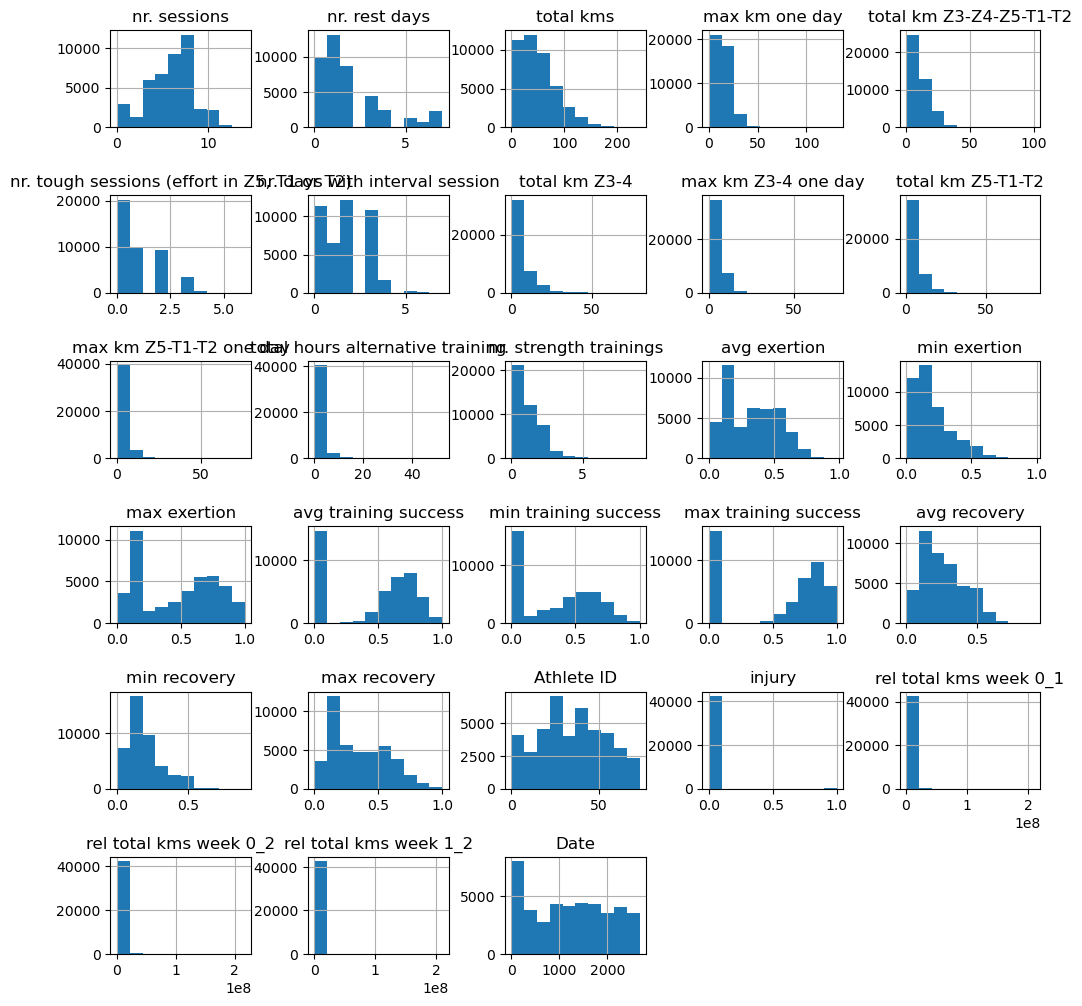

In [15]:
df_week[week_hist_filtered_cols].hist(figsize=(12,12))
plt.subplots_adjust(hspace=0.7, wspace=0.4);

In [16]:
injury_vals_week = df_week.injury.value_counts()
injury_vals_week, str(f"Injuries: {round(injury_vals_week[1] / (injury_vals_week[0]+injury_vals_week[1])*100, 2)}%")

(injury
 0    42223
 1      575
 Name: count, dtype: int64,
 'Injuries: 1.34%')

The histograms above show the distribution of a subset of the weekly data (only the features of the first week of the event phase of 3 weeks, `Athlete ID`, `injury`, `rel total kms week 0_1`, `rel total kms week 0_2`, `rel total kms week 1_2`, and `Date`).


Intensity (km Z>2 and `nr. of intense sessions`) and `alternative training` plots show decaying distributions.

The Plot of `nr. sessions` is left-skewed, `nr. rest days` and `total kms` plots are right-skewed, and `nr. days with interval session` is multiploar.

The `exertion`, `training success`, and `recovery` plots have skewed distributions with high numbers of data points around 0.


The `Athlete ID` plot shows that we have varying numbers of week phases of training data between athletes.

It is apparent in the `injury` plot that we have a highly imbalanced dataset (~1.34% is an injury).

The plots for `rel total kms week X_Y` show that the change in km distance between the weeks doesn't flucuate highly, indicating that the training phases are similar (for example, a rhythm of low-medium-high volume).

The `Date` plot is stable after an initial drop off. This suggests that the dataset contains a stable number of athletes/records over time.

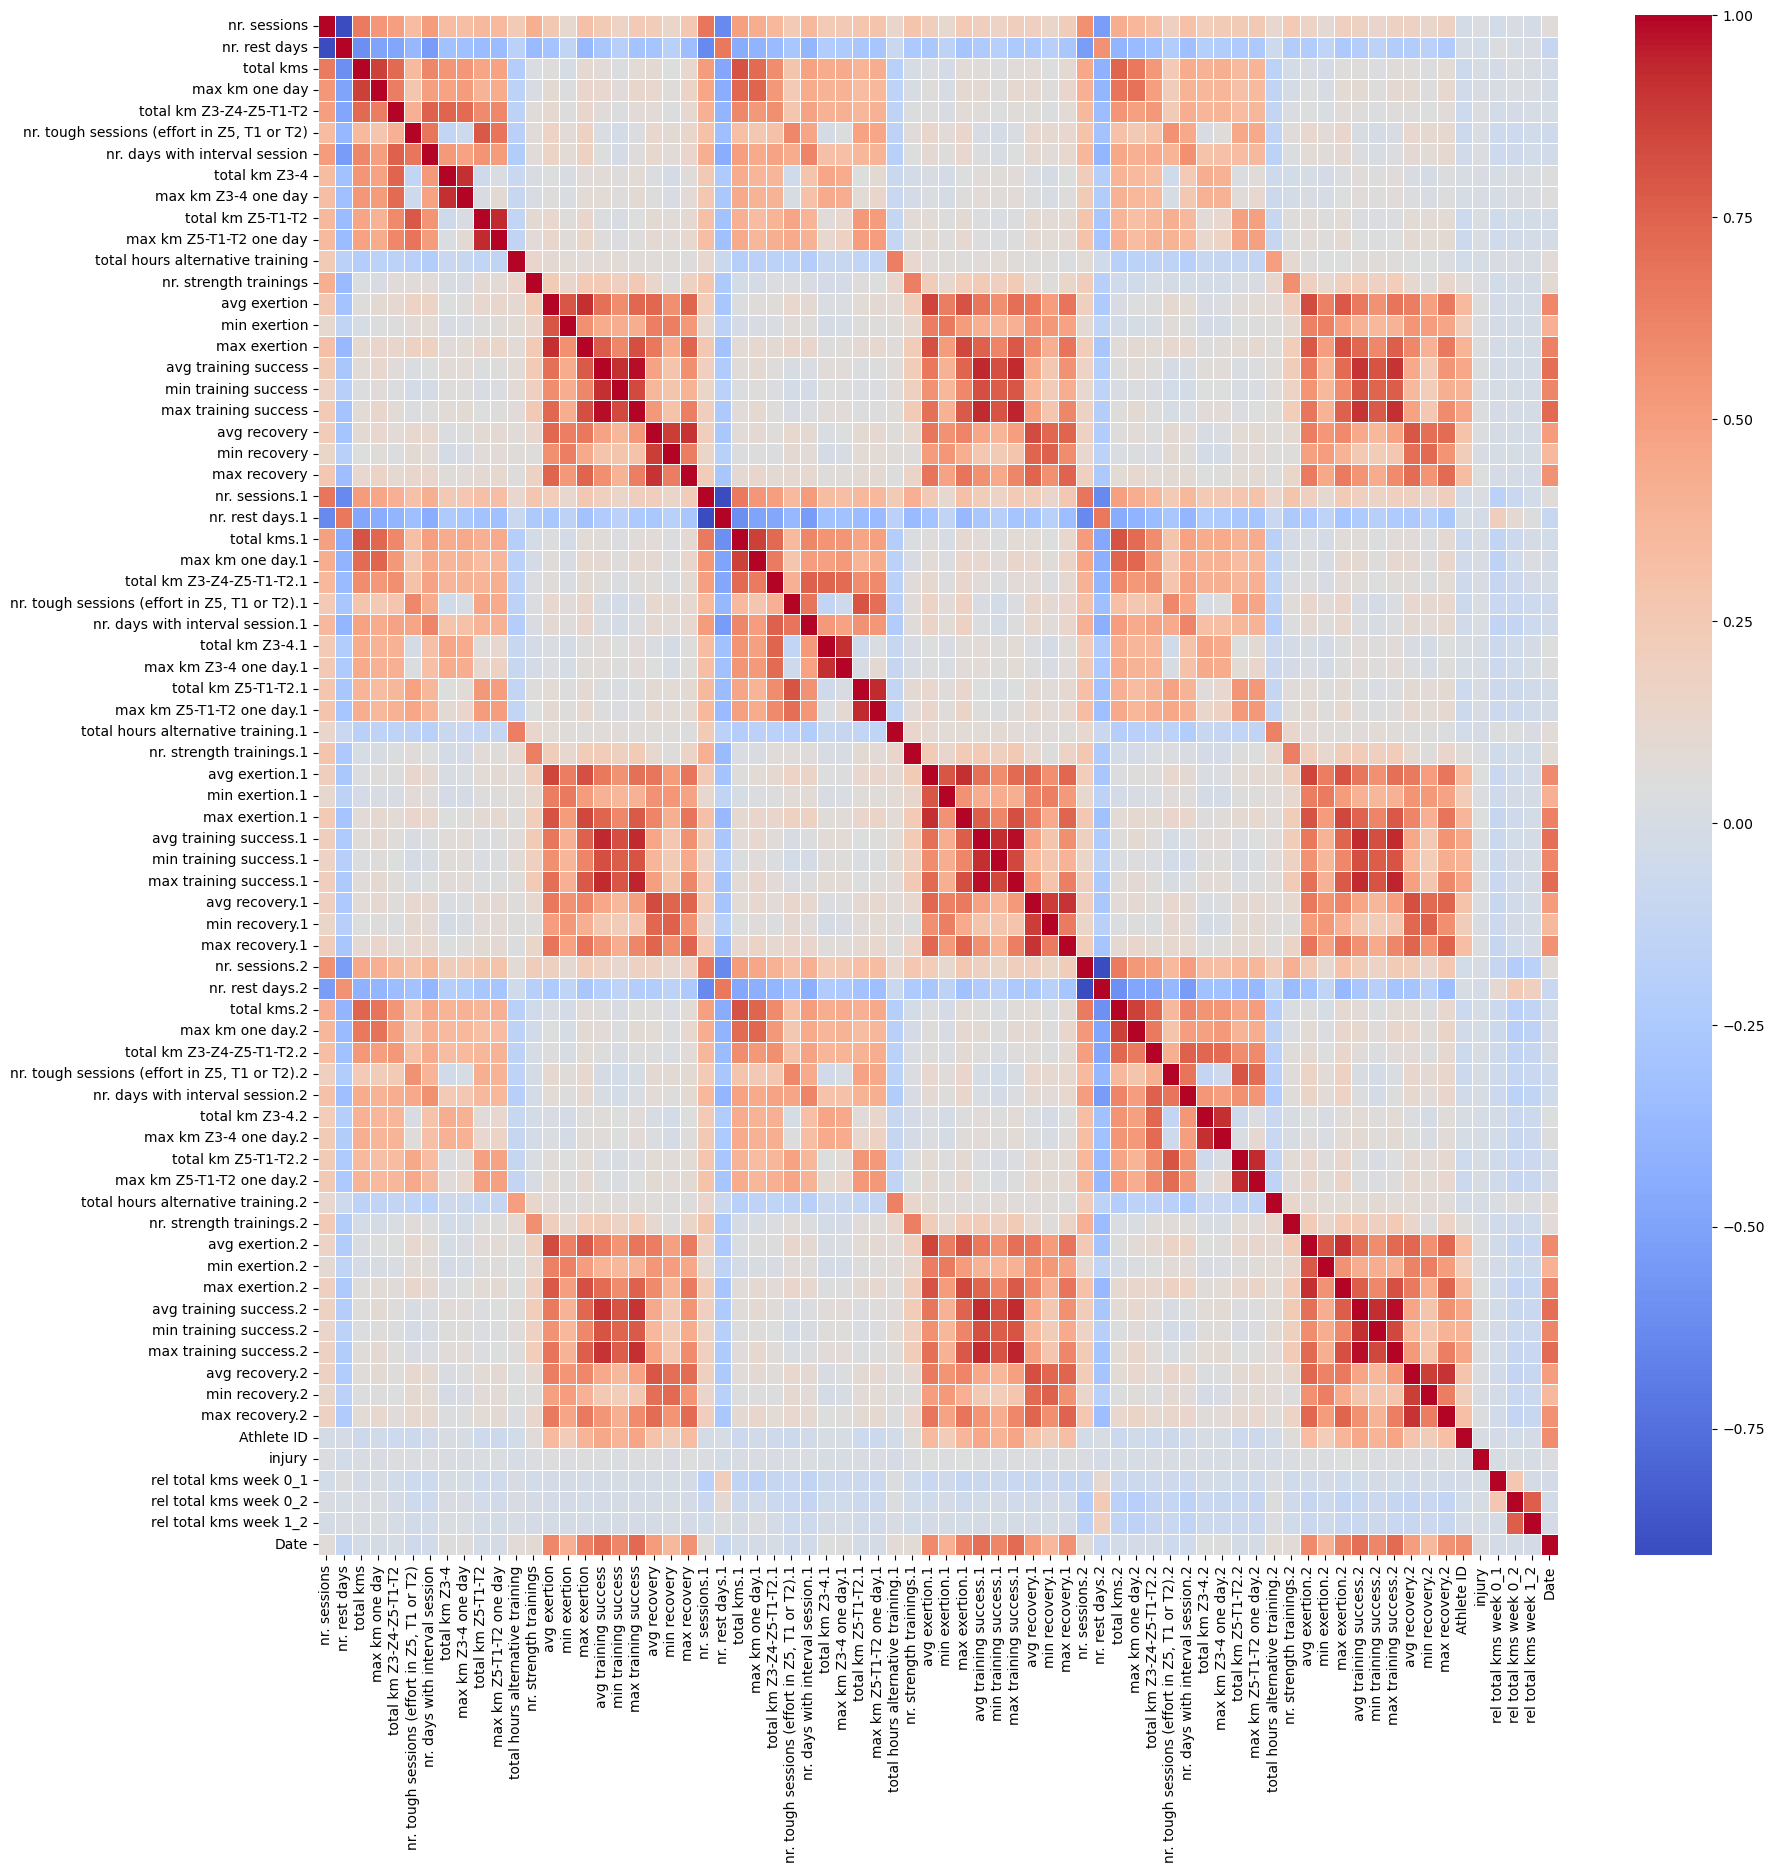

In [17]:
plt.figure(figsize=(20,20))
sns.heatmap(df_week.corr(), annot=False, cmap='coolwarm', linewidths=.5);

The correlation heatmap does not show a linear relationship between any of the features and whether or not an injury occurs.

Moderate to high correlation is visible between the perceived features (exertion, training success, and recovery) of the different weeks, as well as the date. The number of rest days and number of sessions are correlated, as expected.
As mentioned above, there may be a three-week training rhythm. There is a positive relationship between the `rel total kms week X_Y`, with the week of the event presumably being a higher volume week.

The prediction at hand appears to be more complex than a linear problem.

In [18]:
df.isna().any().sum()

0

There are no missing values in the dataset. Based on the previous initial observation, the data appears clean.